### TASK 3 · Car Price Prediction with Machine Learning


## Objective: 
Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

import the library

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, mean_squared_error,r2_score,mean_absolute_error



### Load the dataset

In [28]:
car=pd.read_csv("car data.csv")
car

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [29]:
car.shape

(301, 9)

### Data Cleaning

In [30]:
car.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [31]:
car.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [32]:
car.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [33]:
car.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [34]:
car.duplicated().sum()

np.int64(2)

In [35]:
car.drop_duplicates(inplace=True)

In [36]:
car.duplicated().sum()

np.int64(0)

### Feature Engineering

In [37]:
current_year = datetime.now().year
car['Car_Age']=current_year-car['Year']
car

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


Car age was calculated dynamically using Python’s datetime module so that the feature updates automatically based on the system’s current year.

Brand extraction was not performed because the dataset did not contain manufacturer names in the Car_Name column

### EDA

<Axes: ylabel='Frequency'>

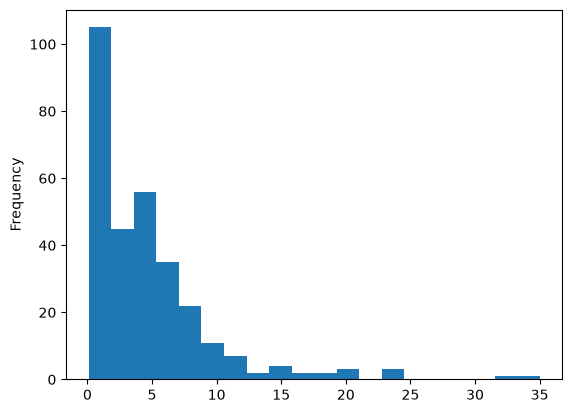

In [38]:
## Distribution of the selling price
car['Selling_Price'].plot(kind='hist',bins=20)

**Observation:** Most cars are concentrated in the lower selling price range, while only a few cars have very high prices. The distribution is positively skewed.

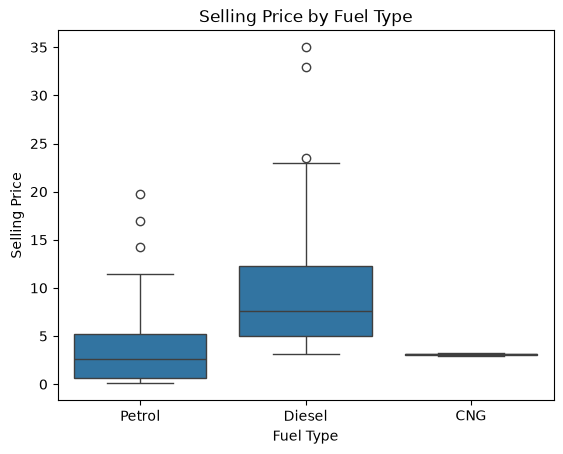

In [39]:
sns.boxplot(x=car['Fuel_Type'], y=car['Selling_Price'], data=car)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

**Observation:** Diesel cars generally have a higher median selling price compared to Petrol cars, while CNG cars tend to have lower selling prices.

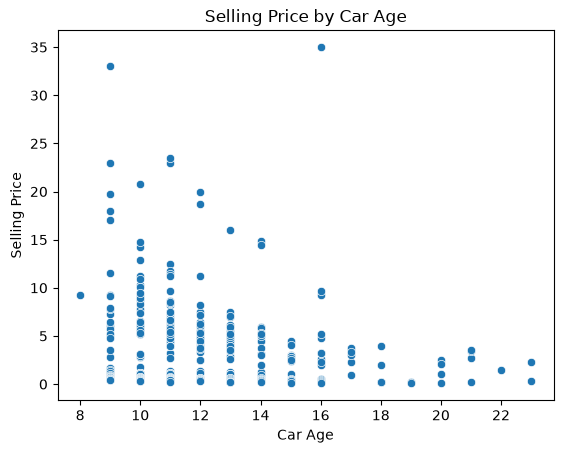

In [40]:
sns.scatterplot(x=car['Car_Age'], y=car['Selling_Price'], data=car)
plt.title("Selling Price by Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

**Observation:** Selling price decreases as car age increases, indicating a negative relationship between car age and selling price.

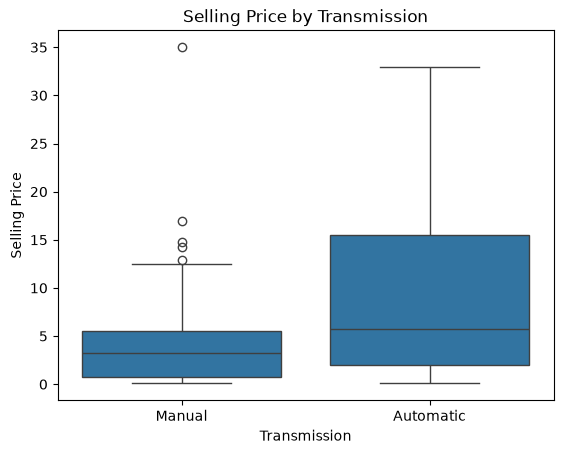

In [41]:

sns.boxplot(x='Transmission', y='Selling_Price', data=car)

plt.title("Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

**Observation:** Automatic cars generally have a higher selling price than manual cars.

In [42]:
# Encode Fuel_Type manually
car['Fuel_Type'] = car['Fuel_Type'].map({
    'CNG': 0,
    'Petrol': 1,
    'Diesel': 2
})

# Encode Seller_Type
car['Seller_Type'] = car['Seller_Type'].map({
    'Dealer': 0,
    'Individual': 1
})

# Encode Transmission
car['Transmission'] = car['Transmission'].map({
    'Automatic': 0,
    'Manual': 1
})

# Check result
car.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,1,0,1,0,12
1,sx4,2013,4.75,9.54,43000,2,0,1,0,13
2,ciaz,2017,7.25,9.85,6900,1,0,1,0,9
3,wagon r,2011,2.85,4.15,5200,1,0,1,0,15
4,swift,2014,4.60,6.87,42450,2,0,1,0,12


In [43]:
car.drop('Car_Name', axis=1, inplace=True)

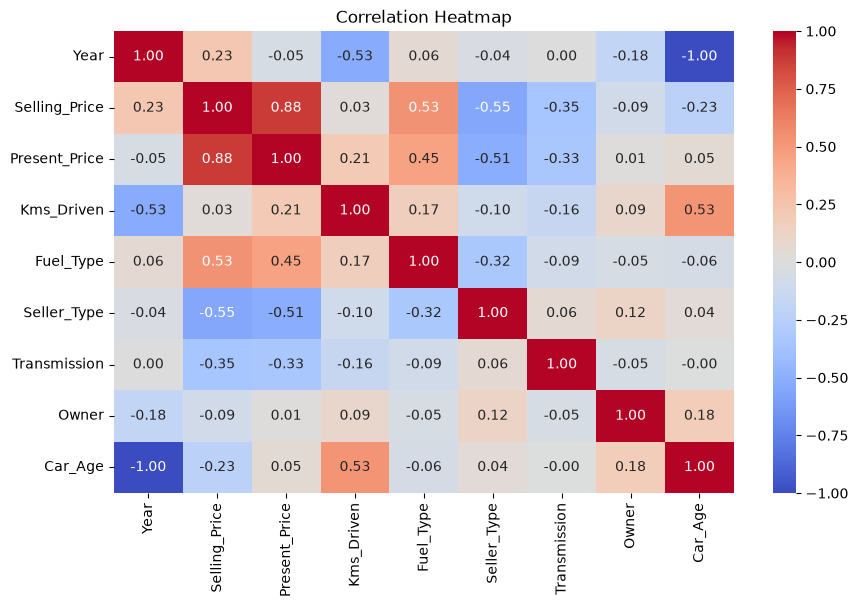

In [44]:
plt.figure(figsize=(10,6))

sns.heatmap(
    car.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [45]:
car.drop(['Year'], axis=1, inplace=True)

### Train/Test Split

In [46]:


x=car.drop(['Selling_Price'], axis=1)
y=car['Selling_Price']

x_train,x_test , y_train , y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [47]:
print("x_train:",x_train.shape)
print("x_test:",x_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

x_train: (239, 7)
x_test: (60, 7)
y_train: (239,)
y_test: (60,)


In [48]:

model= LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.44,-0. , 1.41,...,-1.57, 0.64,-0.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Present_Price','Kms_Driven','Fuel_Type',...,'Transmission','Owner', 'Car_Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.907
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [49]:
predictions= model.predict(x_test)
pd.DataFrame({
    "Actual Price":y_test,
    "Predicted Price":predictions
}).head(10)

,Actual Price,Predicted Price
283,8.99,7.512652
267,8.35,7.768626
166,0.45,1.362824
9,7.45,6.989645
78,5.25,11.186700
280,5.25,4.543358
95,5.85,8.515195
111,1.15,1.698611
5,9.25,8.798821
175,0.38,-0.956081


In [50]:

print("Linear Regression Performance")
print("MAE :", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R²  :", r2_score(y_test, predictions))
print("Accuracy (%):", r2_score(y_test, predictions) * 100)

Linear Regression Performance
MAE : 1.4860503667965572
RMSE: 2.529612763302496
R²  : 0.7517217387116173
Accuracy (%): 75.17217387116173


In [51]:
rf= RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [52]:
rf_pred=rf.predict(x_test)

In [53]:
pd.DataFrame({
    "Actual Price":y_test,
    "Predicted Price":rf_pred
}).head(10)

,Actual Price,Predicted Price
283,8.99,9.5009
267,8.35,8.2570
166,0.45,0.4404
9,7.45,6.8715
78,5.25,16.9710
280,5.25,5.3190
95,5.85,6.9400
111,1.15,1.1790
5,9.25,7.8375
175,0.38,0.2830


In [54]:

print("Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²  :", r2_score(y_test, rf_pred))
print("Accuracy (%):", r2_score(y_test, rf_pred) * 100)

Random Forest Performance
MAE : 1.4554766666666674
RMSE: 3.4425368564959973
R²  : 0.5401800553553859
Accuracy (%): 54.01800553553859


In [57]:
comparsion = pd.DataFrame({
    'Model':['LinearRegression','RandomForestRegressor'],
    'MAE':[mean_absolute_error(y_test, predictions), mean_absolute_error(y_test, rf_pred)],
    'RMSE':[np.sqrt(mean_squared_error(y_test, predictions)), np.sqrt(mean_squared_error(y_test, rf_pred))],
    'R2':[mean_squared_error(y_test, predictions), mean_squared_error(y_test, rf_pred)]
})
comparsion

,Model,MAE,RMSE,R2
0,LinearRegression,1.486050,2.529613,6.398941
1,RandomForestRegressor,1.455477,3.442537,11.851060


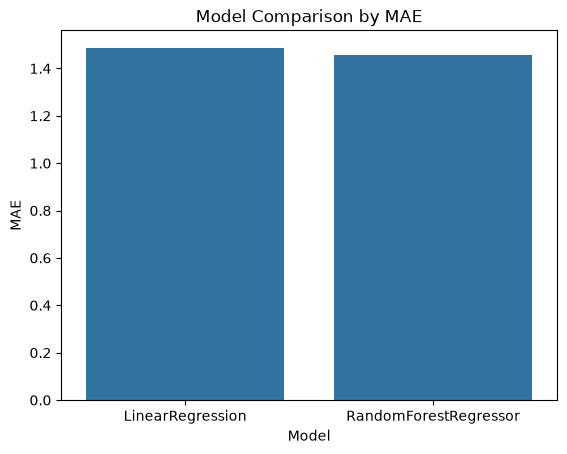

In [58]:
sns.barplot(x='Model', y='MAE',data=comparsion)

plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

## Conclusion

This project developed machine learning models to predict used car selling prices. After data cleaning, feature engineering, exploratory analysis, and model training, the Random Forest Regressor achieved better performance than Linear Regression with lower prediction error and a higher R² score. Therefore, Random Forest was selected as the final model for car price prediction.